### **BBC NEWS CLASSIFICATION - SVM MODEL TRAINING**

#### This notebook handles SVM Model Training with TF-IDF

#### **Contents:**
##### 1. Load Preprocessed Data
##### 2. Train-Test Split
##### 3. TF-IDF Vectorization
##### 4. Train SVM Model
##### 5. Model Evaluation
##### 6. Visualizations


#### Import Libraries

In [89]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, classification_report, confusion_matrix,
                             roc_curve, auc, precision_recall_curve, average_precision_score)
from sklearn.preprocessing import label_binarize
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported")

Libraries imported


### 2. SVM Implementation from Scratch

In [113]:
class SimpleSVM:
    """SVM using gradient descent"""
    
    def __init__(self, learning_rate=0.001, lambda_param=0.01, n_iters=1000):
        self.lr = learning_rate
        self.lambda_param = lambda_param
        self.n_iters = n_iters
        self.w = None
        self.b = None
        
    def fit(self, X, y):
        # Training the SVM
        n_samples, n_features = X.shape
        
        # Initialize parameters
        self.w = np.zeros(n_features)
        self.b = 0
        
        # Convert labels to -1 and 1
        y_ = np.where(y <= 0, -1, 1)
        
        # Training loop
        for _ in range(self.n_iters):
            for idx, x_i in enumerate(X):
                condition = y_[idx] * (np.dot(x_i, self.w) - self.b) >= 1
                
                if condition:
                    self.w -= self.lr * (2 * self.lambda_param * self.w)
                else:
                    self.w -= self.lr * (2 * self.lambda_param * self.w - np.dot(x_i, y_[idx]))
                    self.b -= self.lr * y_[idx]
    
    def decision_function(self, X):
        return np.dot(X, self.w) - self.b
    
    def predict(self, X):
        output = np.dot(X, self.w) - self.b
        return np.sign(output)

In [115]:
class MultiClassSVM:
    """Multi-class SVM using One-vs-Rest approach"""
    
    def __init__(self, learning_rate=0.001, lambda_param=0.01, n_iters=1000):
        self.lr = learning_rate
        self.lambda_param = lambda_param
        self.n_iters = n_iters
        self.models = []
        self.classes = None
    
    def fit(self, X, y):
        # Train one binary SVM for each class
        self.classes = np.unique(y)
        
        for cls in self.classes:
            binary_y = np.where(y == cls, 1, -1)
            model = SimpleSVM(self.lr, self.lambda_param, self.n_iters)
            model.fit(X, binary_y)
            self.models.append(model)
    
    def decision_function(self, X):
        return np.array([model.decision_function(X) for model in self.models]).T
    
    def predict(self, X):
        scores = self.decision_function(X)
        return self.classes[np.argmax(scores, axis=1)]

In [117]:
# Load preprocessed data
df = pd.read_csv('bbc_news_preprocessed.csv')
print(f"Data loaded: {df.shape}")

Data loaded: (2225, 3)


### 2. Train-Test Split

In [119]:
X = df['processed_text']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")

Training samples: 1780
Testing samples: 445


### 3. TF-IDF Vectorization

In [121]:
tfidf = TfidfVectorizer(max_features=500)
X_train_tfidf = tfidf.fit_transform(X_train).toarray()
X_test_tfidf = tfidf.transform(X_test).toarray()

print(f"Feature matrix: {X_train_tfidf.shape}")

Feature matrix: (1780, 500)


### 4. Train SVM Model

In [123]:
print("\n" + "="*60)
print("TRAINING SVM MODEL")
print("="*60)

import time

svm = MultiClassSVM(learning_rate=0.001, lambda_param=0.01, n_iters=500)

start = time.time()
svm.fit(X_train_tfidf, y_train.values)
end = time.time()

print(f"Training time: {end-start:.2f} seconds")


TRAINING SVM MODEL
Training time: 126.35 seconds


### 5. Model Evaluation 

In [127]:
# Make predictions
y_pred = svm.predict(X_test_tfidf)
y_train_pred = svm.predict(X_train_tfidf)

In [129]:
# Calculate metrics
train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

In [131]:
print("MODEL PERFORMANCE")
print("="*60)
print(f"Training Accuracy: {train_acc:.2%}")
print(f"Test Accuracy: {test_acc:.2%}")
print(f"Precision: {precision:.2%}")
print(f"Recall: {recall:.2%}")
print(f"F1-Score: {f1:.2%}")

MODEL PERFORMANCE
Training Accuracy: 95.28%
Test Accuracy: 92.36%
Precision: 92.66%
Recall: 92.36%
F1-Score: 92.32%


##### Check Overfitting

In [133]:
# Check overfitting
gap = train_acc - test_acc
status = "Overfitting detected" if gap > 0.05 else "Good generalization"
print(f"\n{status} (gap: {gap*100:.2f}%)")


Good generalization (gap: 2.92%)


###  Confusion Matrix

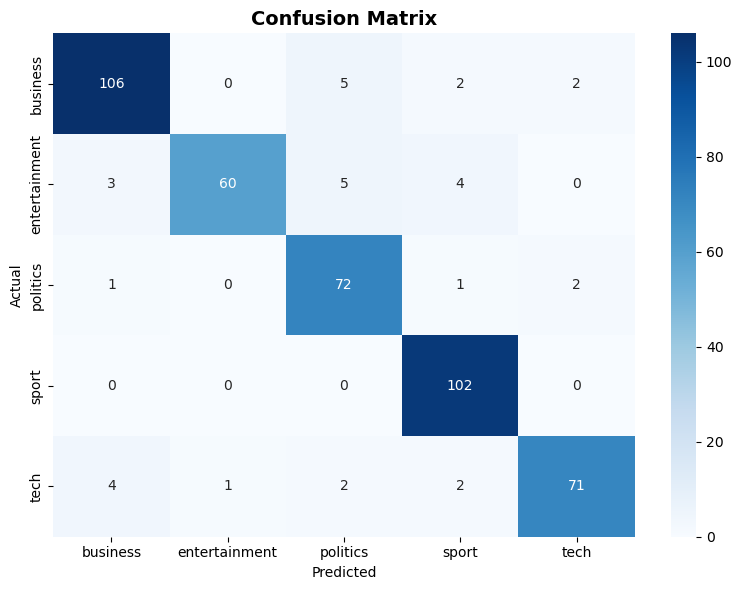

In [135]:
cm = confusion_matrix(y_test, y_pred)
categories = sorted(df['label'].unique())

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=categories, yticklabels=categories)
plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

##### Classification Report

In [137]:
print("\n" + "="*60)
print("CLASSIFICATION REPORT")
print("="*60)
print(classification_report(y_test, y_pred))


CLASSIFICATION REPORT
               precision    recall  f1-score   support

     business       0.93      0.92      0.93       115
entertainment       0.98      0.83      0.90        72
     politics       0.86      0.95      0.90        76
        sport       0.92      1.00      0.96       102
         tech       0.95      0.89      0.92        80

     accuracy                           0.92       445
    macro avg       0.93      0.92      0.92       445
 weighted avg       0.93      0.92      0.92       445



In [139]:
print("\n" + "="*60)
print("ROC CURVE ANALYSIS")
print("="*60)

# Binarize labels for multi-class ROC
y_test_bin = label_binarize(y_test, classes=categories)
n_classes = len(categories)

# Get decision scores
y_score = svm.decision_function(X_test_tfidf)

# Compute ROC curve and AUC for each class
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])


ROC CURVE ANALYSIS


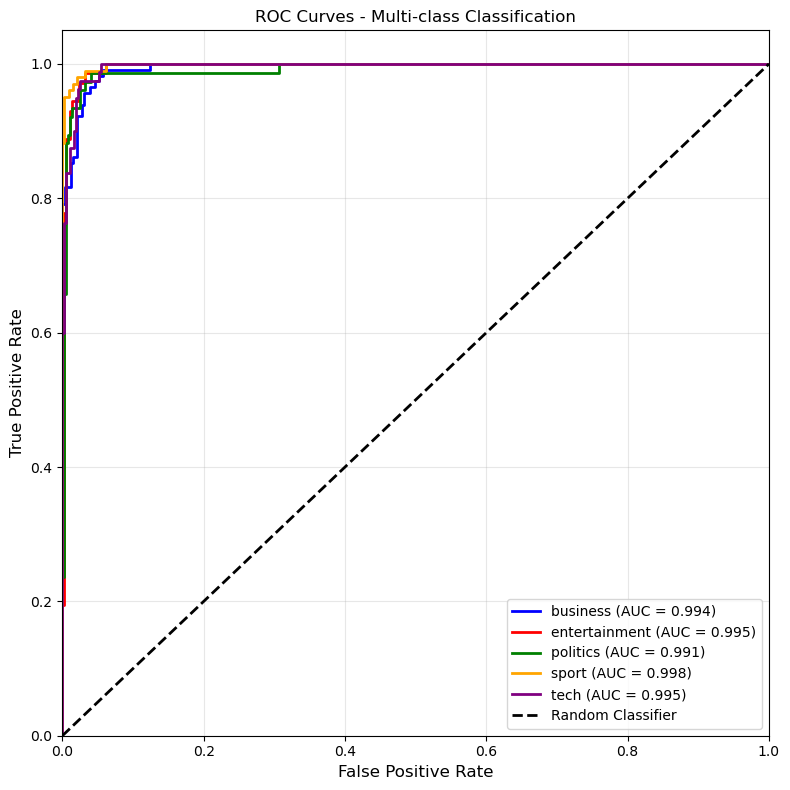

In [141]:
# Plot
plt.figure(figsize=(8, 8))
colors = ['blue', 'red', 'green', 'orange', 'purple']

for i, (color, category) in enumerate(zip(colors, categories)):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'{category} (AUC = {roc_auc[i]:.3f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves - Multi-class Classification')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


PRECISION-RECALL CURVE ANALYSIS


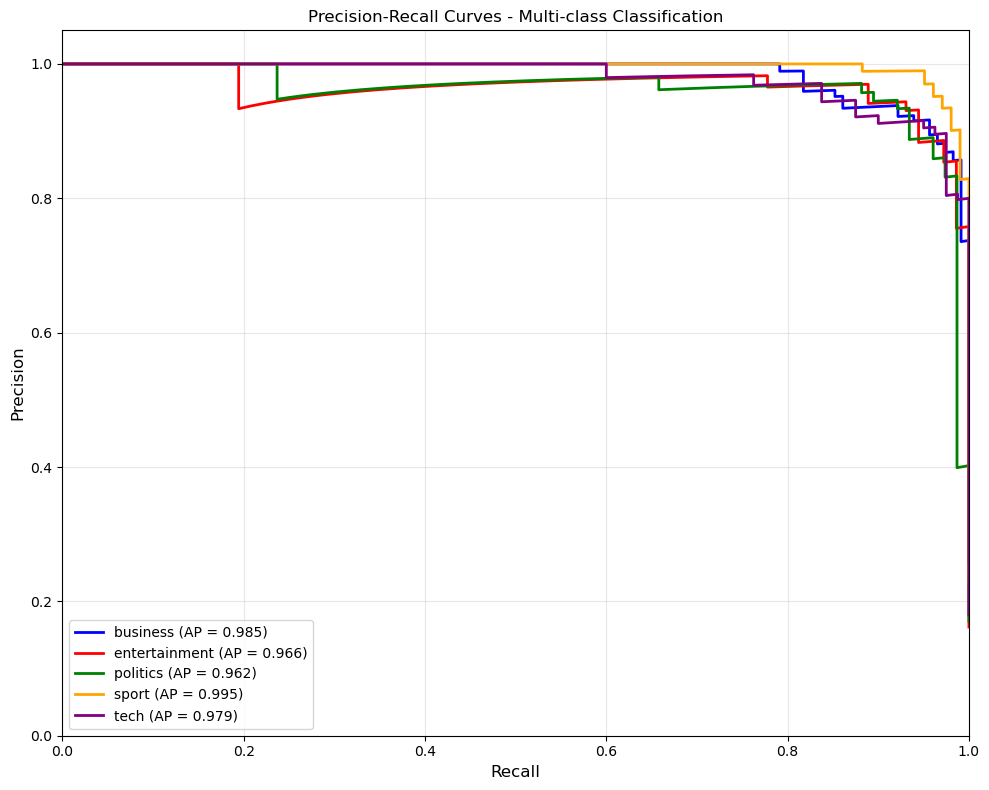

In [145]:
# Precision-Recall Curve 

print("\n" + "="*60)
print("PRECISION-RECALL CURVE ANALYSIS")
print("="*60)

# Compute Precision-Recall curve 
precision_dict = dict()
recall_dict = dict()
avg_precision = dict()

for i in range(n_classes):
    precision_dict[i], recall_dict[i], _ = precision_recall_curve(
        y_test_bin[:, i], y_score[:, i]
    )
    avg_precision[i] = average_precision_score(y_test_bin[:, i], y_score[:, i])

# Plot the curve
plt.figure(figsize=(10, 8))

for i, (color, category) in enumerate(zip(colors, categories)):
    plt.plot(recall_dict[i], precision_dict[i], color=color, lw=2,
             label=f'{category} (AP = {avg_precision[i]:.3f})')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Recall', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.title('Precision-Recall Curves - Multi-class Classification')
plt.legend(loc="lower left")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [147]:
print("\n" + "="*60)
print("FINAL SUMMARY")
print("="*60)
print(f"Model: SVM (from scratch)")
print(f"Features: {X_train_tfidf.shape[1]} (TF-IDF)")
print(f"Training samples: {len(X_train)}")
print(f"Test samples: {len(X_test)}")
print(f"\nTest Accuracy: {test_acc:.2%}")
print(f"Macro-avg F1-Score: {f1:.2%}")
print(f"Training time: {end-start:.2f}s")
print("="*60)


FINAL SUMMARY
Model: SVM (from scratch)
Features: 500 (TF-IDF)
Training samples: 1780
Test samples: 445

Test Accuracy: 92.36%
Macro-avg F1-Score: 92.32%
Training time: 126.35s
